<a href="https://colab.research.google.com/github/olegbend2406-create/CV/blob/main/Prediction_of_the_House_pricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install catboost
import numpy as np
import pandas as pd
import sklearn
from sklearn.ensemble import GradientBoostingRegressor
from pylab import rcParams
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

In [ ]:
train = pd.read_csv('/content/drive/MyDrive/House pricing/train.csv')
test = pd.read_csv('/content/drive/MyDrive/House pricing/test.csv')

In [ ]:
train['SalePrice'].skew()

np.float64(1.8828757597682129)

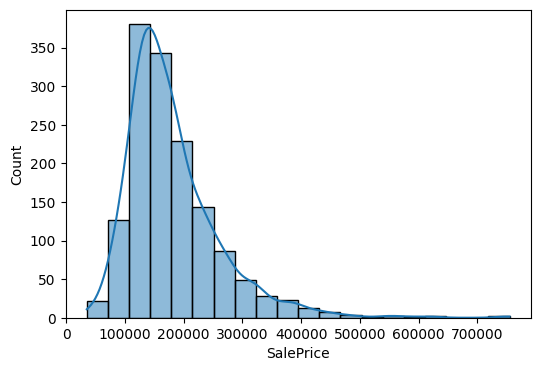

In [ ]:


rcParams['figure.figsize'] = 6, 4
sns.histplot(train['SalePrice'], bins=20, kde=True)
plt.show()

In [ ]:
train['SalePrice'] = np.log1p(train['SalePrice'])

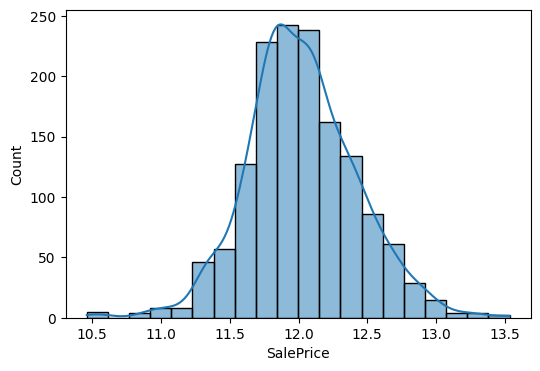

In [ ]:
rcParams['figure.figsize'] = 6, 4
sns.histplot(train['SalePrice'], bins=20, kde=True)
plt.show()

In [ ]:
perc = (train.isnull().sum()/len(train))*100
for column_name, percentage in perc.items():
  if percentage != 0:
    print(f"Column '{column_name}': {percentage:.2f}%")

Column 'LotFrontage': 17.74%
Column 'Alley': 93.77%
Column 'MasVnrType': 59.73%
Column 'MasVnrArea': 0.55%
Column 'BsmtQual': 2.53%
Column 'BsmtCond': 2.53%
Column 'BsmtExposure': 2.60%
Column 'BsmtFinType1': 2.53%
Column 'BsmtFinType2': 2.60%
Column 'Electrical': 0.07%
Column 'FireplaceQu': 47.26%
Column 'GarageType': 5.55%
Column 'GarageYrBlt': 5.55%
Column 'GarageFinish': 5.55%
Column 'GarageQual': 5.55%
Column 'GarageCond': 5.55%
Column 'PoolQC': 99.52%
Column 'Fence': 80.75%
Column 'MiscFeature': 96.30%


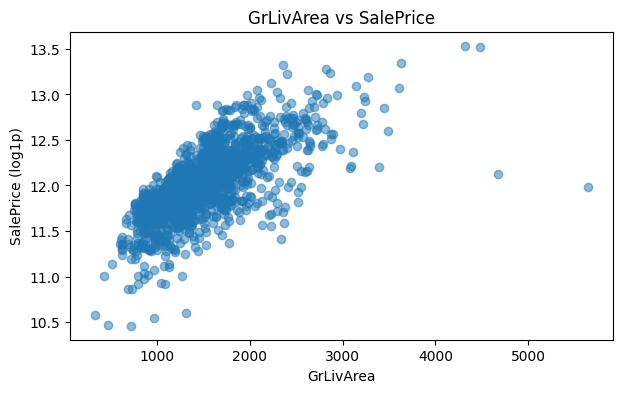

In [ ]:
plt.figure(figsize=(7, 4))
plt.scatter(train['GrLivArea'], train['SalePrice'], alpha=0.5)
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice (log1p)')
plt.title('GrLivArea vs SalePrice')
plt.show()

In [ ]:
def first_clean(train,test):
  #Прибираємо шум від неспівставних даних
  train = train.drop(train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 12.5)].index).reset_index(drop=True)
  #Зберігаємо колонки ID and SalePrice окремо та об'єднуємо 2 вибірки для подальшого очищення
  y_train = train['SalePrice'].values
  test_id = test['Id']
  all_data = pd.concat([train.drop(columns=['Id', 'SalePrice']), test.drop(columns=['Id'])], axis=0).reset_index(drop=True)
  ntrain = train.shape[0]
  ntest = test.shape[0]
  #Робимо підстановку даних для заповнення усіх пропусків
  cols_to_fill_with_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu','GarageType', 'GarageFinish', 'GarageQual', 'GarageCond','BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1','BsmtFinType2','MasVnrType']
  all_data[cols_to_fill_with_none] = all_data[cols_to_fill_with_none].fillna('None')
  cols_to_fill_0 = ['GarageCars','GarageArea','GarageYrBlt','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','BsmtFullBath','BsmtHalfBath','MasVnrArea']
  all_data[cols_to_fill_0] = all_data[cols_to_fill_0].fillna(0)
  all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
  for col in ['MSZoning', 'Electrical', 'KitchenQual', 'SaleType', 'Exterior1st', 'Exterior2nd', 'Functional']:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])
  all_data['Utilities'] = all_data['Utilities'].fillna(all_data['Utilities'].mode()[0])
  return y_train,test_id,all_data,ntrain,ntest


In [ ]:
def feature_engeneering(df):

  all_data = df.copy()
  # Створюємо сильні ознаки за допомогою об'єднання кількох пов'язаних між собою колонок
  all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
  all_data['TotalBaths'] = (all_data['FullBath'] + (0.5 * all_data['HalfBath']) + all_data['BsmtFullBath'] + (0.5 * all_data['BsmtHalfBath']))
  all_data['TotalPorchSF'] = (all_data['OpenPorchSF'] + all_data['3SsnPorch'] + all_data['EnclosedPorch'] + all_data['ScreenPorch'] + all_data['WoodDeckSF'])

  # Вік будинку на момент продажу та чи була реконструкція
  all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']
  all_data['RemodAge'] = all_data['YrSold'] - all_data['YearRemodAdd']
  all_data['IsRemodeled'] = (all_data['YearBuilt'] != all_data['YearRemodAdd']).astype(int)

  # Колонки для виведення числових значень наявності об'єктів
  all_data['HasPool'] = (all_data['PoolArea'] > 0).astype(int)
  all_data['HasGarage'] = (all_data['GarageArea'] > 0).astype(int)
  all_data['HasBsmt'] = (all_data['TotalBsmtSF'] > 0).astype(int)
  all_data['HasFireplace'] = (all_data['Fireplaces'] > 0).astype(int)

  #Колонки нижче мають чіткий порядок категорізації, варто перезаписати його числами
  ordinal_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
  ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
  for col in ordinal_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].map(ordinal_map).fillna(0)

  # Перетворюємо числові коди на категоріальні рядки
  all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)
  all_data['YrSold'] = all_data['YrSold'].astype(str)
  all_data['MoSold'] = all_data['MoSold'].astype(str)
  all_data = pd.get_dummies(all_data).astype(int)

  return all_data


In [ ]:
#Функція для розрахунку метрики RMSE
def cv_rmse(model, X=X_train, y=y_train):

    rmse = -cross_val_score(model, X, y, scoring="neg_root_mean_squared_error", cv=kf)

    return rmse


In [ ]:
#Первинна очистка даних
y_train,test_id,all_data,ntrain,ntest = first_clean(train,test)

In [ ]:
#Генерація ключових ознак
Feature = feature_engeneering(all_data)

In [ ]:
#Ділимо наш масив назад на тренувальний та тестовий. Створюємо K-Fold Cross-Validation змінну (kf)
X_train = Feature.iloc[:ntrain, :].copy()
X_test = Feature.iloc[ntrain:, :].copy()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
#Навчаємо модель на традиційному градієнтному бустингу
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
  )
score_gbr = cv_rmse(gbr)
print(f"GradientBoostingRegressor CV Score: {score_gbr.mean():.4f} (std: {score_gbr.std():.4f})")

GradientBoostingRegressor CV Score: 0.1216 (std: 0.0046)


In [ ]:
#Тренуємо більш сучасні моделі
model_lgb = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=15,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1
)

score_lgb = cv_rmse(model_lgb)
print(f"LightGBM CV Score: {score_lgb.mean():.4f} (std: {score_lgb.std():.4f})")

model_xgb = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

score_xgb = cv_rmse(model_xgb)
print(f"XGBoost CV Score: {score_xgb.mean():.4f} (std: {score_xgb.std():.4f})")

model_cat = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=0
)

score_cat = cv_rmse(model_cat)
print(f"CatBoost CV Score: {score_cat.mean():.4f} (std: {score_cat.std():.4f})")

LightGBM CV Score: 0.1203 (std: 0.0092)
XGBoost CV Score: 0.1159 (std: 0.0065)
CatBoost CV Score: 0.1136 (std: 0.0065)


In [ ]:
# Масиви для збереження OOF-прогнозів на train
oof_lgb = np.zeros(len(X_train))
oof_xgb = np.zeros(len(X_train))
oof_cat = np.zeros(len(X_train))

# Проходимо по тих самих фолдах
for train_idx, val_idx in kf.split(X_train):
    X_tr, y_tr = X_train.iloc[train_idx], y_train[train_idx]
    X_va = X_train.iloc[val_idx]

    # Тренуємо та прогнозуємо валідацію
    model_lgb.fit(X_tr, y_tr)
    oof_lgb[val_idx] = model_lgb.predict(X_va)

    model_xgb.fit(X_tr, y_tr)
    oof_xgb[val_idx] = model_xgb.predict(X_va)

    model_cat.fit(X_tr, y_tr)
    oof_cat[val_idx] = model_cat.predict(X_va)

# Зважуємо прогнози (більша вага сильнішим моделям)
blend_oof = (0.50 * oof_cat) + (0.35 * oof_xgb) + (0.15 * oof_lgb)

blend_score = root_mean_squared_error(y_train, blend_oof)
print(f"OOF CatBoost Score: {root_mean_squared_error(y_train, oof_cat):.4f}")
print(f"OOF XGBoost Score:  {root_mean_squared_error(y_train, oof_xgb):.4f}")
print(f"OOF LightGBM Score: {root_mean_squared_error(y_train, oof_lgb):.4f}")
print("---------------------------------------")
print(f"🔥 Blended Ensemble Score: {blend_score:.4f}")

OOF CatBoost Score: 0.1138
OOF XGBoost Score:  0.1161
OOF LightGBM Score: 0.1206
---------------------------------------
🔥 Blended Ensemble Score: 0.1131


In [ ]:
# 1. Фінальне навчання на всіх даних
model_lgb.fit(X_train, y_train)
model_xgb.fit(X_train, y_train)
model_cat.fit(X_train, y_train)

# 2. Прогнози на тестовому наборі (у логарифмах)
preds_lgb = model_lgb.predict(X_test)
preds_xgb = model_xgb.predict(X_test)
preds_cat = model_cat.predict(X_test)

# 3. Блендинг у логарифмічному просторі
final_log_preds = (0.50 * preds_cat) + (0.35 * preds_xgb) + (0.15 * preds_lgb)

# 4. Повернення масштабу цін у долари: exp(y) - 1
final_prices = np.expm1(final_log_preds).round(2)

# 5. Збереження submission.csv
sub = pd.DataFrame({
    'Id': test_id,
    'SalePrice': final_prices
})
sub.to_csv('submission.csv', index=False)
print("Файл submission.csv успішно сформовано! Перші 5 рядків:")
print(sub.head())

Файл submission.csv успішно сформовано! Перші 5 рядків:
     Id  SalePrice
0  1461  126461.30
1  1462  161712.47
2  1463  184488.02
3  1464  198500.19
4  1465  186985.05


In [ ]:
#1118th place in the LeaderBoard

In [2]:
!git status

fatal: not a git repository (or any of the parent directories): .git
